In [63]:
import numpy as np

# -----------------------------------------------------------------------------
# Toy MC neutrino event generator - truth level
# -----------------------------------------------------------------------------
# This is a deliberately simple, non-physics-like generator.
# It follows the simulation chain :
#
#   1. Decide whether the event is CC or NC.
#   2. If CC, generate exactly one muon.
#   3. If CC, draw the muon kinetic energy from a double-Gaussian model.
#   4. Draw the muon direction from an exponential distribution in cos(theta),
#      normalized with sinh factor.
#   5. For protons, neutrons, and pions:
#        - draw the particle multiplicity from a Poisson distribution
#        - draw the kinetic energy from a decaying exponential
#        - draw the direction isotropically
#   6. Convert kinetic energy + direction into four-vector components.
#
# -----------------------------------------------------------------------------

# Particle masses in GeV/c^2
M_MU = 0.10566
M_P  = 0.93827
M_N  = 0.93957
M_PI = 0.13957


def sample_positive_normal(rng, mean, sigma):
    """
    Draw from a normal distribution, but reject negative values.
    
    """
    x = rng.normal(mean, sigma)
    while x < 0:
        x = rng.normal(mean, sigma)
    return x


def sample_exponential_kinetic_energy(rng, k):
    """
    Draw kinetic energy from a decaying exponential distribution.

    The parameter k as a negative decay constant,
    so the PDF is proportional to exp(k * T) for T >= 0 with k < 0.

    Equivalent positive rate:
        lambda = -k
    and then T ~ Exponential(scale = 1 / lambda).

    Example:
        k = -8  ->  scale = 0.125 GeV
    """
    if k >= 0:
        raise ValueError("Exponential decay constant k should be negative.")
    return rng.exponential(scale=1.0 / (-k))


def sample_cos_theta_exponential(rng, k):
    """
    Sample u = cos(theta) from the normalized distribution

        f(u) = [k / (2 sinh(k))] * exp(k u),   -1 <= u <= 1

    using inverse transform sampling.

    The inverse-CDF formula is:

        u = (1/k) * log( exp(-k) + r * (exp(k) - exp(-k)) )

    where r is uniform on [0, 1].

    """
    r = rng.uniform(0.0, 1.0)
    return (1.0 / k) * np.log(np.exp(-k) + r * (np.exp(k) - np.exp(-k)))


def sample_isotropic_direction(rng):
    """
    Sample an isotropic direction.

    Returns:
        u    = cos(theta)
        phi  = azimuthal angle in [0, 2pi)
        sin_theta = sqrt(1 - u^2)
    """
    u = rng.uniform(-1.0, 1.0)
    phi = rng.uniform(0.0, 2.0 * np.pi)
    sin_theta = np.sqrt(max(0.0, 1.0 - u * u))
    return u, phi, sin_theta


def kinetic_to_four_vector(T, mass, u, phi):
    """
    Convert kinetic energy and direction into a four-vector.

    Parameters
    ----------
    T : float
        Kinetic energy in GeV.
    mass : float
        Particle mass in GeV/c^2.
    u : float
        cos(theta).
    phi : float
        Azimuthal angle in radians.

    Returns
    -------
    dict with keys:
        E, p, px, py, pz
    """
    # Total energy
    E = T + mass

    # Momentum magnitude from relativistic relation:
    # p^2 = E^2 - m^2 = T(T + 2m)
    p = np.sqrt(max(0.0, T * (T + 2.0 * mass)))

    # Cartesian components
    sin_theta = np.sqrt(max(0.0, 1.0 - u * u))
    px = p * sin_theta * np.cos(phi)
    py = p * sin_theta * np.sin(phi)
    pz = p * u

    return {
        "E": E,
        "p": p,
        "px": px,
        "py": py,
        "pz": pz,
    }


def generate_event(event_id,
                   rng=None,
                   p_cc=0.67,          # probability of CC 
                   k_mu=2.5,           # for muon angular distribution
                   mu_g1_mean=0.30,    # muon momentum
                   mu_g1_sigma=0.15,   # 
                   mu_g2_mean=0.80,    # 
                   mu_g2_sigma=0.50,   # 
                   mu_g2_rel_w=0.15,   # 
                   lambda_p=1.0,       # proton multiplicity mean
                   k_p=-4.0,           # proton energy spectrum factor 
                   lambda_n=1.0,       # neutron multiplicity mean
                   k_n=-4.0,           # neutron energy spectrum factor
                   lambda_pi=0.5,      # pion multiplicity mean
                   k_pi=-2.0           # pion energy spectrum factor
                  ):
    """
    Generate one toy event.

    Parameters
    ----------
    event_id : int
        Event identifier.
    rng : numpy.random.Generator or None
        Random number generator. If None, a default generator is created.
    p_cc : float
        Probability that the event is CC. Else NC.
    k_mu : float
        Shape parameter for the muon cos(theta) exponential distribution.
        Larger positive values -> more forward-peaked muons.
    mu_g1_mean, mu_g1_sigma : float
        Mean and sigma for the first muon Gaussian component.
    mu_g2_mean, mu_g2_sigma : float
        Mean and sigma for the second muon Gaussian component.
    mu_g2_rel_w : float
        Relative weight of Gaussian 2 compared to Gaussian 1.
        If Gaussian 1 has weight 1.0, then Gaussian 2 has weight 0.15.
    lambda_p, k_p : float
        Proton multiplicity mean and exponential decay constant.
    lambda_n, k_n : float
        Neutron multiplicity mean and exponential decay constant.
    lambda_pi, k_pi : float
        Pion multiplicity mean and exponential decay constant.

    Returns
    -------
    event : dict
        A simple event record with interaction type and final-state particles.
    """
    if rng is None:
        rng = np.random.default_rng()

    event = {
        "event_id": event_id,
        "is_cc": None,
        "particles": []
    }

    # -------------------------------------------------------------------------
    # Step 1: Decide whether the event is CC or NC
    # -------------------------------------------------------------------------
    is_cc = rng.uniform(0.0, 1.0) < p_cc
    event["is_cc"] = is_cc

    # -------------------------------------------------------------------------
    # Step 2: If CC, generate exactly one muon
    # -------------------------------------------------------------------------
    if is_cc:
        # The muon kinetic energy comes from a two-component Gaussian mixture.
        # The second Gaussian has lower probability:
        #   w2 = 0.15 * w1
        # P probability of component 2 is:
        #   w2 / (w1 + w2)
        w1 = 1.0
        w2 = mu_g2_rel_w
        p2 = w2 / (w1 + w2)

        if rng.uniform(0.0, 1.0) < p2:
            T_mu = sample_positive_normal(rng, mu_g2_mean, mu_g2_sigma)
        else:
            T_mu = sample_positive_normal(rng, mu_g1_mean, mu_g1_sigma)

        # Draw the muon direction from the exponential cos(theta) model.
        u_mu = sample_cos_theta_exponential(rng, k_mu)
        phi_mu = rng.uniform(0.0, 2.0 * np.pi)

        mu_vec = kinetic_to_four_vector(T_mu, M_MU, u_mu, phi_mu)

        event["particles"].append({
            "name": "mu-",
            "pdg": 13,
            "mass": M_MU,
            "T": T_mu,
            **mu_vec
        })

    # -------------------------------------------------------------------------
    # Step 3: Generate protons
    # -------------------------------------------------------------------------
    # Number of protons is Poisson distributed.
    n_protons = rng.poisson(lambda_p)

    for _ in range(n_protons):
        T_p = sample_exponential_kinetic_energy(rng, k_p)

        # Protons are isotropic in this toy model.
        u, phi, _ = sample_isotropic_direction(rng)

        p_vec = kinetic_to_four_vector(T_p, M_P, u, phi)

        event["particles"].append({
            "name": "p",
            "pdg": 2212,
            "mass": M_P,
            "T": T_p,
            **p_vec
        })

    # -------------------------------------------------------------------------
    # Step 4: Generate neutrons
    # -------------------------------------------------------------------------
    n_neutrons = rng.poisson(lambda_n)

    for _ in range(n_neutrons):
        T_n = sample_exponential_kinetic_energy(rng, k_n)

        # Neutrons are isotropic in this toy model.
        u, phi, _ = sample_isotropic_direction(rng)

        n_vec = kinetic_to_four_vector(T_n, M_N, u, phi)

        event["particles"].append({
            "name": "n",
            "pdg": 2112,
            "mass": M_N,
            "T": T_n,
            **n_vec
        })

    # -------------------------------------------------------------------------
    # Step 5: Generate pions
    # -------------------------------------------------------------------------
    n_pions = rng.poisson(lambda_pi)

    for _ in range(n_pions):
        T_pi = sample_exponential_kinetic_energy(rng, k_pi)

        # Choose pion charge with equal probability.
        pion_choice = rng.integers(0, 3)
        if pion_choice == 0:
            name, pdg = "pi+", 211
        elif pion_choice == 1:
            name, pdg = "pi-", -211
        else:
            name, pdg = "pi0", 111

        # Pions are isotropic in this toy model.
        u, phi, _ = sample_isotropic_direction(rng)

        pi_vec = kinetic_to_four_vector(T_pi, M_PI, u, phi)

        event["particles"].append({
            "name": name,
            "pdg": pdg,
            "mass": M_PI,
            "T": T_pi,
            **pi_vec
        })

    return event

In [64]:
# -----------------------------------------------------------------------------
# Generate a sample of toy MC events
# -----------------------------------------------------------------------------
#
# This creates a Python list called 'events'.
#
# Each element of the list is one event:
#
#     events[0]
#     events[1]
#     ...
#
# Each event is a dictionary containing:
#
#     event["event_id"]
#     event["is_cc"]
#     event["particles"]
#
# where event["particles"] is itself a list of particle dictionaries.
#
# No external packages (such as pandas) are required.
# -----------------------------------------------------------------------------

# Number of events to generate
n_events = 10000

# Create a reproducible random number generator
rng = np.random.default_rng(seed=12345)

# Container for all generated events
events = []

# Generate events
for event_id in range(n_events):
    event = generate_event(event_id, rng)
    events.append(event)

print(f"Generated {len(events)} events.")

Generated 10000 events.


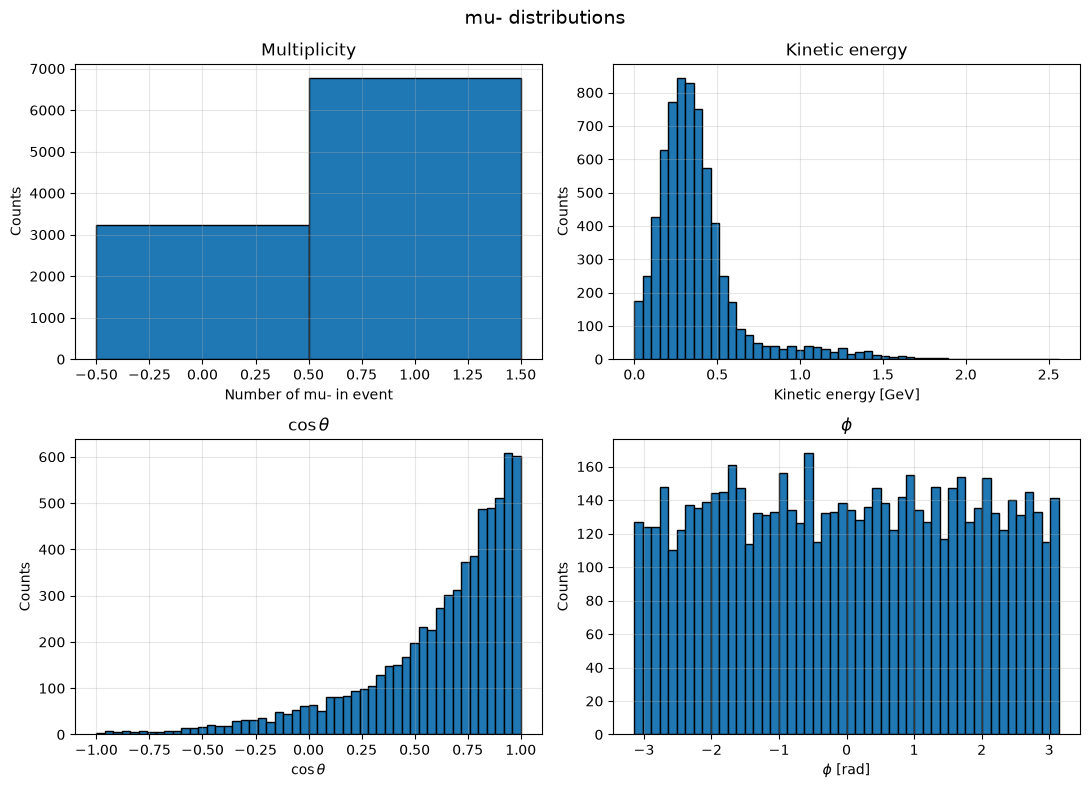

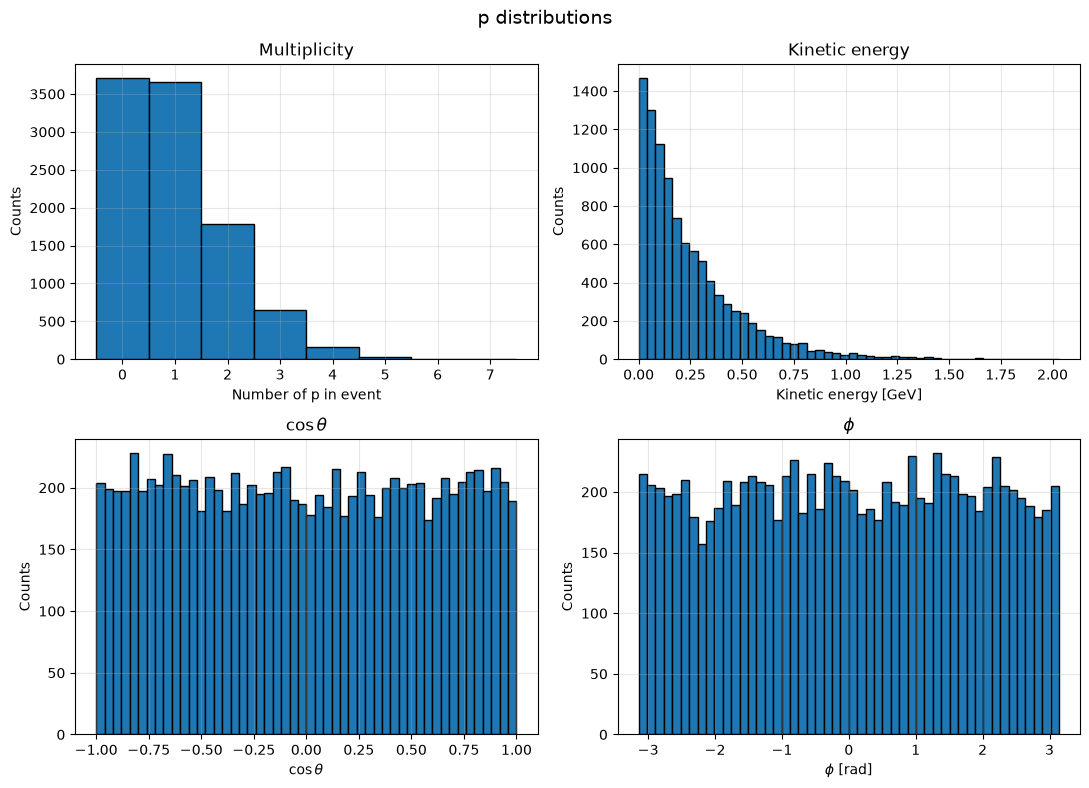

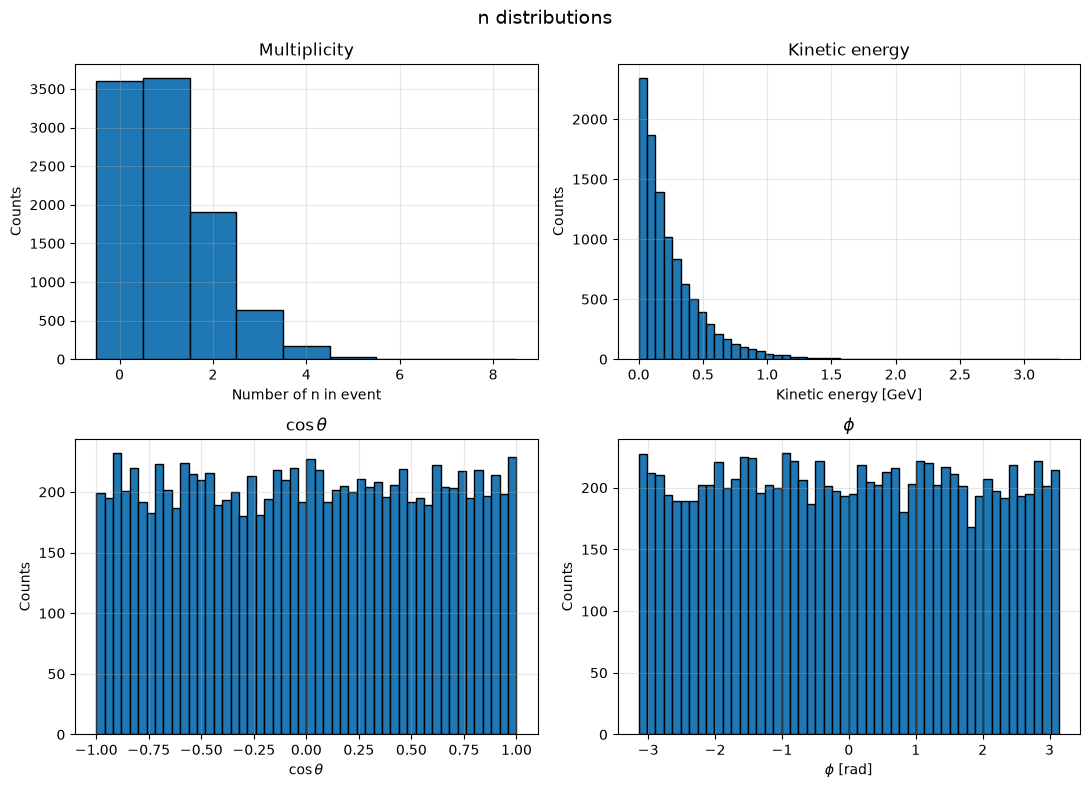

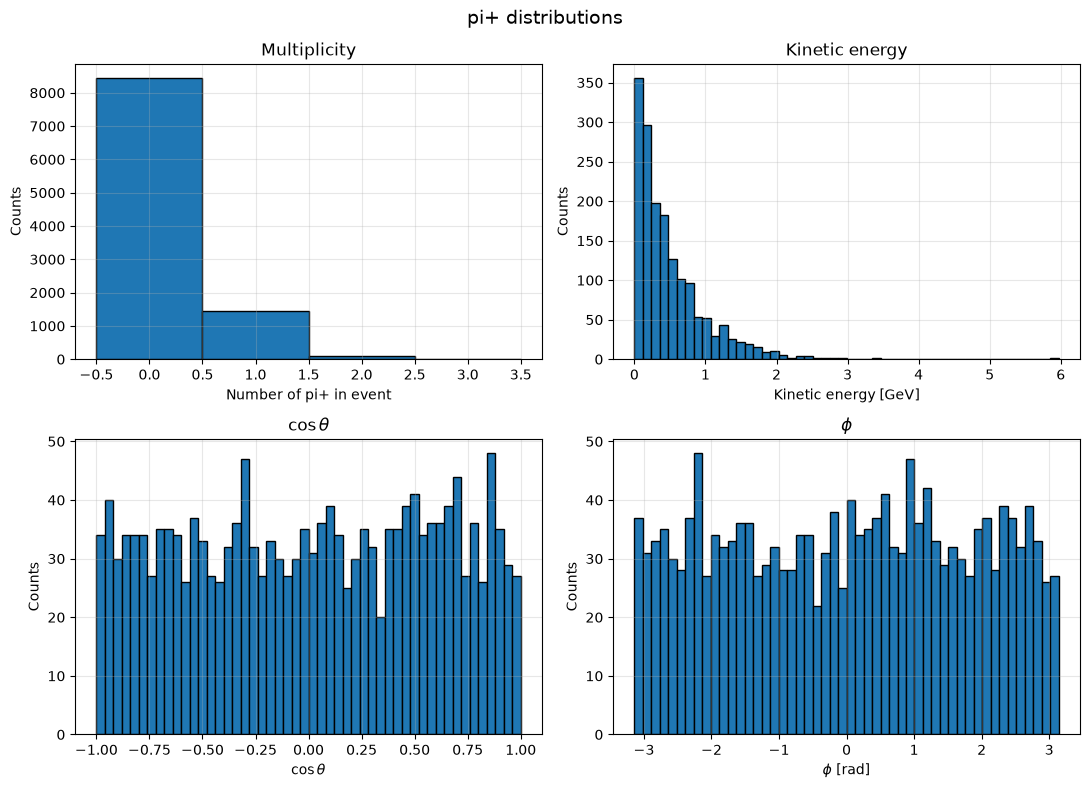

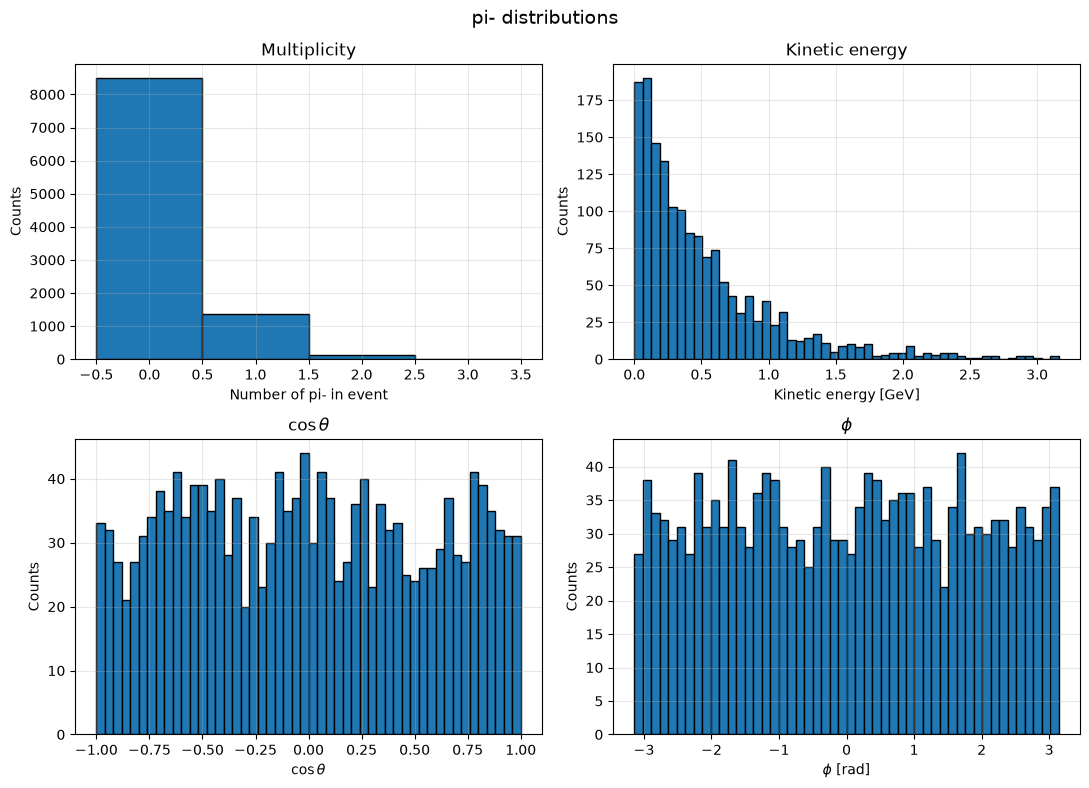

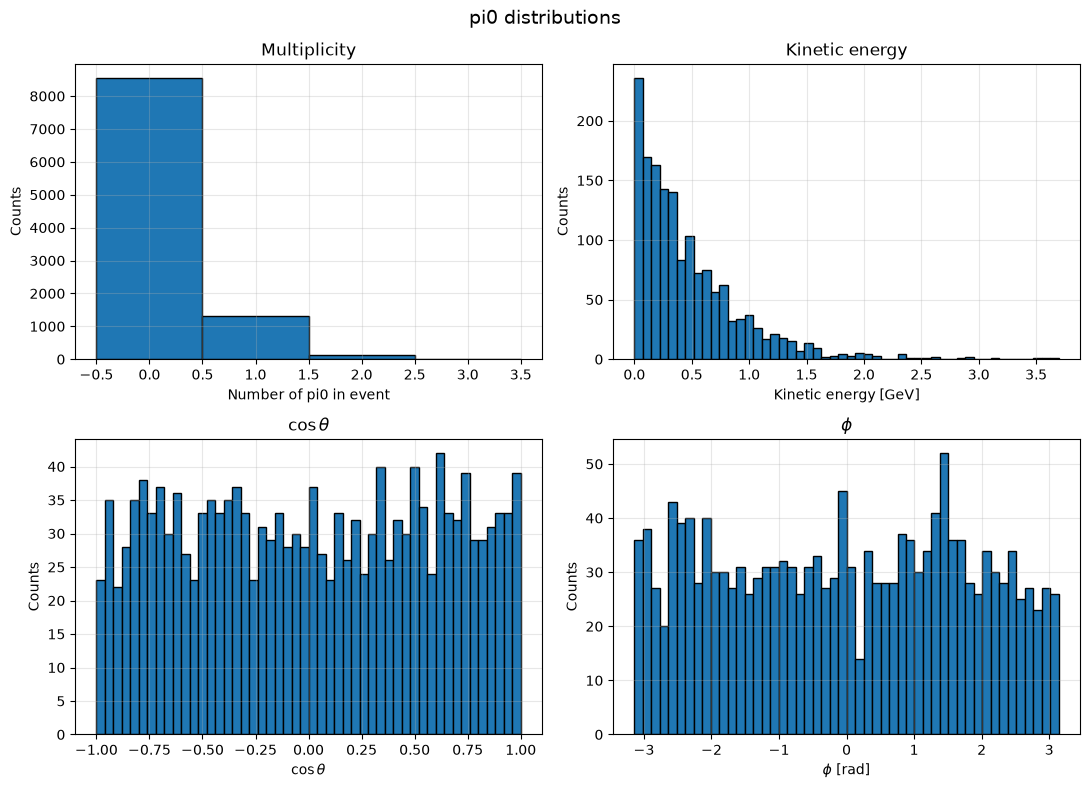

In [65]:
# -----------------------------------------------------------------------------
# Plot particle multiplicity, kinetic energy, cos(theta), and phi
# for each particle species in the toy sample.
#
# This version works directly with the plain Python 'events' list.
# It does not require pandas.
#
# Particle species shown:
#   - mu-
#   - proton
#   - neutron
#   - pi+
#   - pi-
#   - pi0
# -----------------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Define the particle species we want to study.
# Each entry is (label, pdg_code).
species = [
    ("mu-", 13),
    ("p", 2212),
    ("n", 2112),
    ("pi+", 211),
    ("pi-", -211),
    ("pi0", 111),
]

# -------------------------------------------------------------------------
# Collect event-level multiplicities and particle-level kinematics
# -------------------------------------------------------------------------

multiplicities = {name: [] for name, _ in species}
kinetic_energy = {name: [] for name, _ in species}
cos_theta = {name: [] for name, _ in species}
phi = {name: [] for name, _ in species}

for event in events:
    # Count how many of each species appear in this event
    counts = {name: 0 for name, _ in species}

    for particle in event["particles"]:
        pdg = particle["pdg"]

        for name, code in species:
            if pdg == code:
                counts[name] += 1

                # Kinetic energy is stored directly in the particle record
                kinetic_energy[name].append(particle["T"])

                # cos(theta) = pz / p, with a safety check for p = 0
                p = particle["p"]
                if p > 0:
                    cos_theta[name].append(particle["pz"] / p)
                else:
                    cos_theta[name].append(np.nan)

                # Azimuthal angle in the transverse plane
                phi[name].append(np.arctan2(particle["py"], particle["px"]))
                break

    # Save the per-event multiplicity for each species
    for name, _ in species:
        multiplicities[name].append(counts[name])

# -------------------------------------------------------------------------
# Make one figure per particle species
# Each figure has four panels:
#   1) multiplicity per event
#   2) kinetic energy
#   3) cos(theta)
#   4) phi
# -------------------------------------------------------------------------

for name, _ in species:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    fig.suptitle(f"{name} distributions", fontsize=14)

    # -------------------------------------------------------------
    # 1) Number of particles of this type per event
    # -------------------------------------------------------------
    ax = axes[0, 0]
    max_mult = max(multiplicities[name]) if multiplicities[name] else 0
    bins = np.arange(-0.5, max_mult + 1.5, 1)
    ax.hist(multiplicities[name], bins=bins, density=False, edgecolor="black")
    ax.set_xlabel(f"Number of {name} in event")
    ax.set_ylabel("Counts")
    ax.set_title("Multiplicity")
    ax.grid(alpha=0.3)

    # -------------------------------------------------------------
    # 2) Kinetic energy
    # -------------------------------------------------------------
    ax = axes[0, 1]
    ax.hist(kinetic_energy[name], bins=50, density=False, edgecolor="black")
    ax.set_xlabel("Kinetic energy [GeV]")
    ax.set_ylabel("Counts")
    ax.set_title("Kinetic energy")
    ax.grid(alpha=0.3)

    # -------------------------------------------------------------
    # 3) cos(theta)
    # -------------------------------------------------------------
    ax = axes[1, 0]
    cos_vals = np.array(cos_theta[name], dtype=float)
    cos_vals = cos_vals[np.isfinite(cos_vals)]
    ax.hist(cos_vals, bins=50, range=(-1, 1), density=False, edgecolor="black")
    ax.set_xlabel(r"$\cos\theta$")
    ax.set_ylabel("Counts")
    ax.set_title(r"$\cos\theta$")
    ax.grid(alpha=0.3)

    # -------------------------------------------------------------
    # 4) phi
    # -------------------------------------------------------------
    ax = axes[1, 1]
    ax.hist(phi[name], bins=50, range=(-np.pi, np.pi), density=False, edgecolor="black")
    ax.set_xlabel(r"$\phi$ [rad]")
    ax.set_ylabel("Counts")
    ax.set_title(r"$\phi$")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [69]:
import numpy as np

# -----------------------------------------------------------------------------
# Detector smearing with efficiency + particle misidentification
# -----------------------------------------------------------------------------
#
# Event structure for file writing:
#
#   event = {
#       "event_id": ...,
#       "is_cc": ...,
#       "particles": [truth particles with particle_id],
#       "reco_particles": [reco particles with truth_particle_id]
#   }
#
# The truth-to-reco connection is explicit and stable:
#   truth particle i  <->  reco particle with truth_particle_id = i
#
# If a particle fails efficiency, it is still kept in reco_particles, but all
# reco quantities are set to None.
# -----------------------------------------------------------------------------

MASS_BY_PDG = {
    13: 0.10566,
    2212: 0.93827,
    2112: 0.93957,
    211: 0.13957,
    -211: 0.13957,
    111: 0.13498,
}

RESOLUTION_PARAMS = {
    "mu":  {"a": 0.02, "b": 0.050, "c": 0.01},
    "em":  {"a": 0.03, "b": 0.050, "c": 0.03},
    "had": {"a": 0.03, "b": 0.100, "c": 0.10},
}

EFFICIENCY_PARAMS = {
    "mu":  {"e": 0.8, "k": 20.0, "T0": 0.02},
    "p":   {"e": 0.8, "k": 5.0,  "T0": 0.3},
    "n":   {"e": 0.5, "k": 3.0,  "T0": 0.23},
    "pi±": {"e": 0.8, "k": 10.0, "T0": 0.35},
    "pi0": {"e": 0.7, "k": 10.0, "T0": 0.2},
}

# Misidentification probabilities.
# These are conditional probabilities for a true species to be reconstructed
# as another species.
MISID_PROBS = {
    13:   [(-211, 0.10), (211, 0.05)],                       # mu- -> pi- / pi+
    2212: [(2112, 0.10), (211, 0.05), (-211, 0.10)],         # p -> n / pi+ / pi-
    2112: [(2212, 0.10), (111, 0.10)],                       # n -> p / pi0
    211:  [(13, 0.10), (2212, 0.05), (-211, 0.10)],          # pi+ -> mu- / p / pi-
    -211: [(13, 0.10), (211, 0.10), (2212, 0.10)],           # pi- -> mu- / pi+ / p
    111:  [(2112, 0.10)],                                    # pi0 -> n
}

PDG_NAME = {
    13: "mu-",
    2212: "p",
    2112: "n",
    211: "pi+",
    -211: "pi-",
    111: "pi0",
}


def wrap_phi(phi):
    return (phi + np.pi) % (2.0 * np.pi) - np.pi


def particle_category(pdg):
    if abs(pdg) == 13:
        return "mu"
    if pdg == 111:
        return "em"
    return "had"


def particle_efficiency_key(pdg):
    if abs(pdg) == 13:
        return "mu"
    if pdg == 2212:
        return "p"
    if pdg == 2112:
        return "n"
    if abs(pdg) == 211:
        return "pi±"
    if pdg == 111:
        return "pi0"
    return "pi±"


def particle_efficiency(T, pdg):
    key = particle_efficiency_key(pdg)
    params = EFFICIENCY_PARAMS[key]
    eff = params["e"] * np.tanh(params["k"] * (T - params["T0"]))
    return float(np.clip(eff, 0.0, 1.0))


def momentum_component_sigma(p_component, category):
    params = RESOLUTION_PARAMS[category]
    p_abs = abs(p_component)
    return params["a"] * np.sqrt(p_abs) + params["b"] + params["c"] * p_abs


def smear_particle_id(true_pdg, rng):
    """
    Given a true particle type, return the reconstructed particle type.

    The probabilities are applied after the particle has passed efficiency and
    has been smeared.
    """
    choices = MISID_PROBS.get(true_pdg, [])
    r = rng.uniform(0.0, 1.0)
    cumulative = 0.0

    for reco_pdg, prob in choices:
        cumulative += prob
        if r < cumulative:
            return reco_pdg

    # If none of the mis-ID branches fire, keep the correct identity.
    return true_pdg


def smear_particle(particle, rng):
    """
    Smear one truth particle.

    The returned dictionary keeps the truth information and adds reco fields.
    If the particle fails efficiency, the reco fields are set to None.
    """
    true_pdg = particle["pdg"]
    true_mass = MASS_BY_PDG.get(true_pdg, particle["mass"])
    category = particle_category(true_pdg)

    # -------------------------------------------------------------------------
    # Step 1: Apply efficiency using the TRUE kinetic energy
    # -------------------------------------------------------------------------
    T_true = particle["T"]
    eff = particle_efficiency(T_true, true_pdg)
    detected = rng.uniform(0.0, 1.0) < eff

    # -------------------------------------------------------------------------
    # Step 2: If not detected, keep the particle record but leave reco empty
    # -------------------------------------------------------------------------
    if not detected:
        return {
            **particle,
            "eff": eff,
            "detected": False,
            "pdg_reco": None,
            "name_reco": None,
            "px_reco": None,
            "py_reco": None,
            "pz_reco": None,
            "p_reco": None,
            "E_reco": None,
            "T_reco": None,
            "cos_theta_reco": None,
            "phi_reco": None,
        }

    # -------------------------------------------------------------------------
    # Step 3: Smear the momentum components
    # -------------------------------------------------------------------------
    px_true = particle["px"]
    py_true = particle["py"]
    pz_true = particle["pz"]

    sigma_px = momentum_component_sigma(px_true, category)
    sigma_py = momentum_component_sigma(py_true, category)
    sigma_pz = momentum_component_sigma(pz_true, category)

    px_reco = px_true + rng.normal(0.0, sigma_px)
    py_reco = py_true + rng.normal(0.0, sigma_py)
    pz_reco = pz_true + rng.normal(0.0, sigma_pz)

    p_reco = np.sqrt(px_reco**2 + py_reco**2 + pz_reco**2)
    E_reco = np.sqrt(p_reco**2 + true_mass**2)
    T_reco = E_reco - true_mass
    cos_theta_reco = pz_reco / p_reco if p_reco > 0 else 1.0
    phi_reco = wrap_phi(np.arctan2(py_reco, px_reco))

    # -------------------------------------------------------------------------
    # Step 4: Apply particle misidentification
    # -------------------------------------------------------------------------
    pdg_reco = smear_particle_id(true_pdg, rng)
    name_reco = PDG_NAME.get(pdg_reco, str(pdg_reco))

    return {
        **particle,
        "eff": eff,
        "detected": True,
        "pdg_reco": pdg_reco,
        "name_reco": name_reco,
        "px_reco": px_reco,
        "py_reco": py_reco,
        "pz_reco": pz_reco,
        "p_reco": p_reco,
        "E_reco": E_reco,
        "T_reco": T_reco,
        "cos_theta_reco": cos_theta_reco,
        "phi_reco": phi_reco,
    }


def smear_event(event, rng):
    """
    Smear all particles in an event.

    Output event structure:
        - particles: truth particles, each with particle_id
        - reco_particles: reco particles, each with truth_particle_id
    """
    truth_particles = []
    reco_particles = []

    for particle_id, particle in enumerate(event["particles"]):
        truth_particle = dict(particle)
        truth_particle["particle_id"] = particle_id
        truth_particles.append(truth_particle)

        reco_particle = smear_particle(truth_particle, rng)
        reco_particle["truth_particle_id"] = particle_id
        reco_particles.append(reco_particle)

    return {
        **event,
        "particles": truth_particles,
        "reco_particles": reco_particles,
    }


# Build smeared events
rng_smear = np.random.default_rng(67890)
smeared_events = [smear_event(event, rng_smear) for event in events]

print(f"Created smeared copy of {len(smeared_events)} events.")

Created smeared copy of 10000 events.


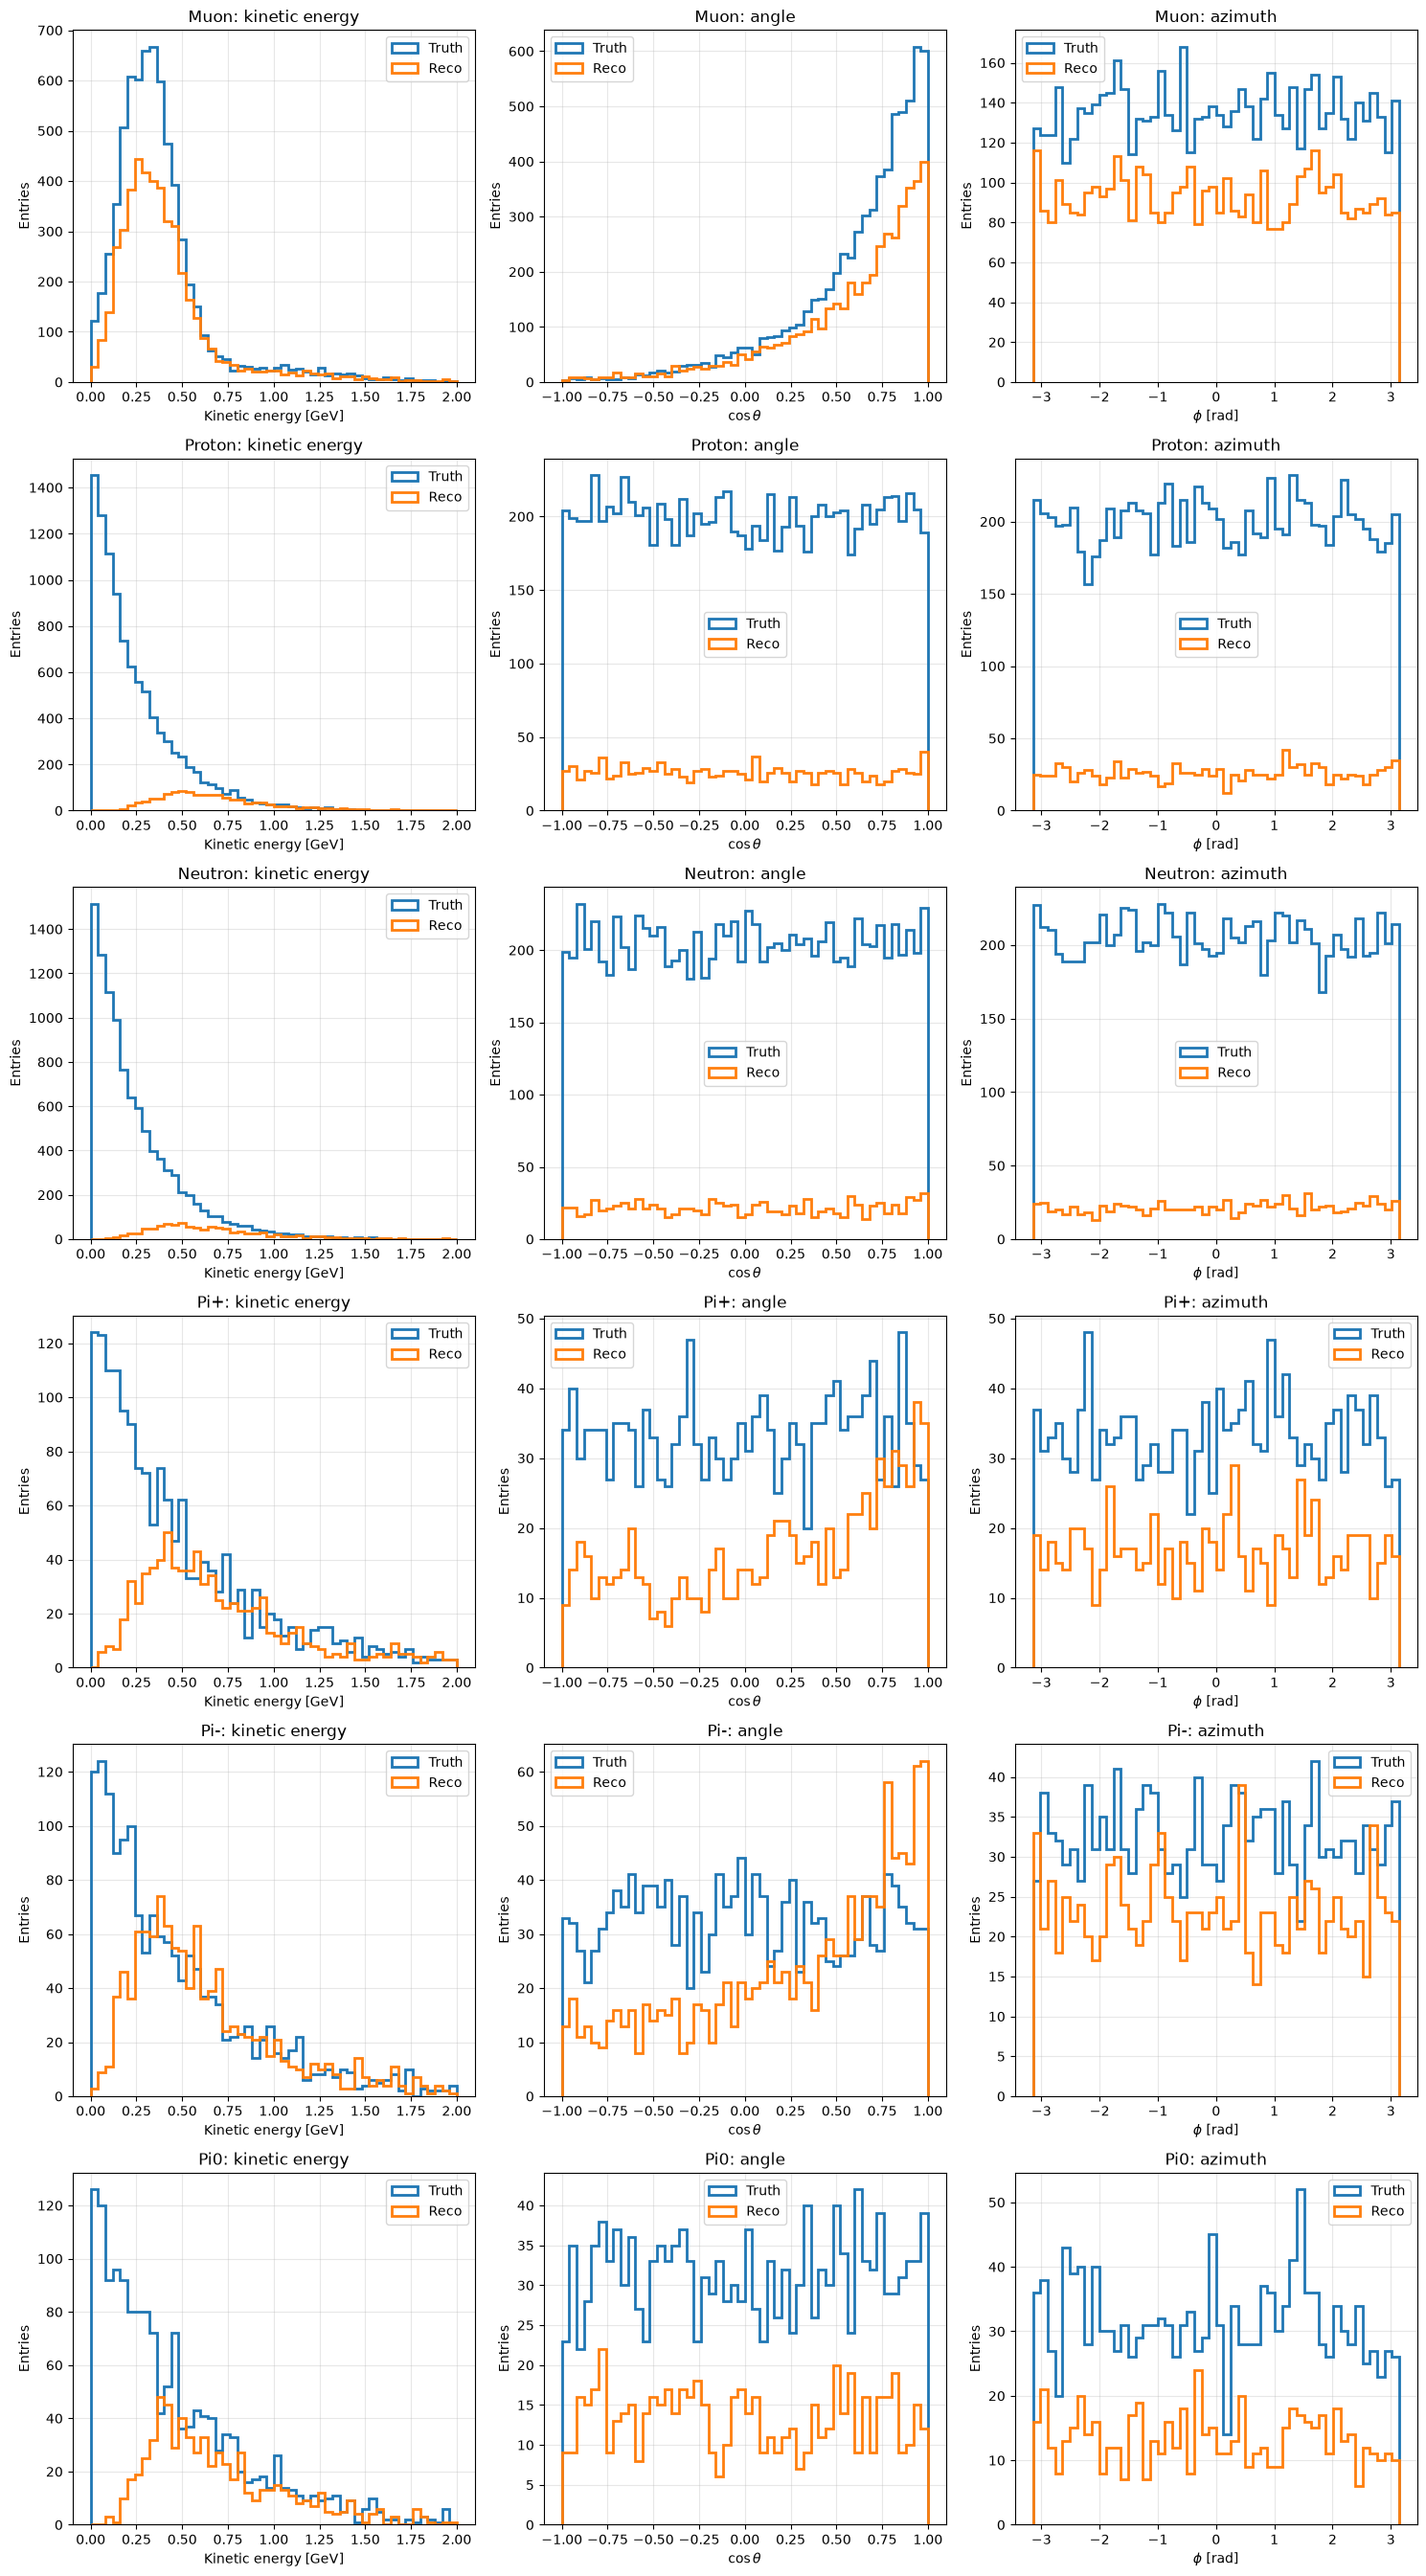

In [70]:
# -----------------------------------------------------------------------------
# Compare true and reconstructed particle distributions
#
# Truth sample:
#   - particles selected by true PDG code
#
# Reco sample:
#   - particles selected by reconstructed PDG code only
#
# This means misidentified particles are NOT counted in the reco histogram
# for their true species.
# -----------------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

species = [
    ("Muon", 13),
    ("Proton", 2212),
    ("Neutron", 2112),
    ("Pi+", 211),
    ("Pi-", -211),
    ("Pi0", 111),
]

fig, axes = plt.subplots(len(species), 3, figsize=(15, 4.5 * len(species)))

for row, (label, pdg) in enumerate(species):
    T_true, T_reco = [], []
    cost_true, cost_reco = [], []
    phi_true, phi_reco = [], []

    # -------------------------------------------------------------------------
    # Truth sample: select by true PDG code
    # -------------------------------------------------------------------------
    for event in events:
        for p in event["particles"]:
            if p["pdg"] != pdg:
                continue

            T_true.append(p["T"])
            cost_true.append(p["pz"] / p["p"] if p["p"] > 0 else np.nan)
            phi_true.append(np.arctan2(p["py"], p["px"]))

    # -------------------------------------------------------------------------
    # Reco sample: select by reconstructed PDG code only
    # -------------------------------------------------------------------------
    for event in smeared_events:
        for p in event["reco_particles"]:
            if not p["detected"]:
                continue
            if p["pdg_reco"] != pdg:
                continue

            T_reco.append(p["T_reco"])
            cost_reco.append(p["cos_theta_reco"])
            phi_reco.append(p["phi_reco"])

    # -------------------------------------------------------------------------
    # Kinetic energy
    # -------------------------------------------------------------------------
    ax = axes[row, 0]
    ax.hist(T_true, bins=50, range=(0, 2), histtype="step", linewidth=2, label="Truth")
    ax.hist(T_reco, bins=50, range=(0, 2), histtype="step", linewidth=2, label="Reco")
    ax.set_xlabel("Kinetic energy [GeV]")
    ax.set_ylabel("Entries")
    ax.set_title(f"{label}: kinetic energy")
    ax.grid(alpha=0.3)
    ax.legend()

    # -------------------------------------------------------------------------
    # cos(theta)
    # -------------------------------------------------------------------------
    ax = axes[row, 1]
    ax.hist(cost_true, bins=50, range=(-1, 1), histtype="step", linewidth=2, label="Truth")
    ax.hist(cost_reco, bins=50, range=(-1, 1), histtype="step", linewidth=2, label="Reco")
    ax.set_xlabel(r"$\cos\theta$")
    ax.set_ylabel("Entries")
    ax.set_title(f"{label}: angle")
    ax.grid(alpha=0.3)
    ax.legend()

    # -------------------------------------------------------------------------
    # phi
    # -------------------------------------------------------------------------
    ax = axes[row, 2]
    ax.hist(phi_true, bins=50, range=(-np.pi, np.pi), histtype="step", linewidth=2, label="Truth")
    ax.hist(phi_reco, bins=50, range=(-np.pi, np.pi), histtype="step", linewidth=2, label="Reco")
    ax.set_xlabel(r"$\phi$ [rad]")
    ax.set_ylabel("Entries")
    ax.set_title(f"{label}: azimuth")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [71]:
import json
import numpy as np

def json_converter(obj):
    """Convert NumPy objects into ordinary Python objects."""

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        if np.isnan(obj):
            return None
        return float(obj)

    if isinstance(obj, np.bool_):
        return bool(obj)

    raise TypeError(f"Cannot serialize {type(obj)}")


output_file = "toy_events.jsonl"

with open(output_file, "w") as f:

    for event in smeared_events:
        json.dump(event, f, default=json_converter)
        f.write("\n")

print(f"Wrote {len(smeared_events)} events to {output_file}")

Wrote 10000 events to toy_events.jsonl


In [1]:
import os
from pathlib import Path

print("Current working directory:")
print(os.getcwd())
print()

print("Files in this directory:")
for p in sorted(Path(".").iterdir()):
    print(p.name)

Current working directory:
/drive/notebooks

Files in this directory:
Intro.ipynb
Lorenz.ipynb
Untitled3.ipynb
Untitled5.ipynb
cpp-third-party-libs.ipynb
cpp-tiny-ray-tracer.ipynb
cpp.ipynb
k-to-pis-plot.ipynb
k0-to-pis.png
k0_decay_rates.png
k0_decay_rates_physics_faithful.pdf
k0_decay_rates_physics_faithful.png
neutrino-toy-mc.ipynb
r.ipynb
sqlite.ipynb
toy_events.jsonl
